# IPL Match Analysis Using Python

## Understanding Toss Impact, Match Phases, and Player Performance in IPL

### Created By: Nitesh
### Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

---

# Introduction

The Indian Premier League (IPL) is one of the most competitive T20 cricket leagues in the world.  
This project analyzes IPL ball-by-ball data to discover patterns related to:

1. Toss advantage
2. Match-winning phases
3. Top-performing players

The dataset contains ball-by-ball IPL match information including batters, bowlers, runs, wickets, toss results, and match winners.

---

# Objective

This analysis aims to answer the following questions:

- Do teams that win the toss also win more matches?
- Which match phase contributes most to winning?
- Who are the top-performing batters and bowlers across recent IPL seasons?

---

# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
ipl = pd.read_csv("ipl_matches.csv", low_memory=False)

# Check first 5 rows
print(ipl.head())

   match_id        date season                  event  \
0   1082591  2017-04-05   2017  Indian Premier League   
1   1082591  2017-04-05   2017  Indian Premier League   
2   1082591  2017-04-05   2017  Indian Premier League   
3   1082591  2017-04-05   2017  Indian Premier League   
4   1082591  2017-04-05   2017  Indian Premier League   

                                       venue       city                team1  \
0  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   
1  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   
2  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   
3  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   
4  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1  Royal Challengers B

# Dataset Overview

Before analysis, it is important to understand the structure of the dataset.

The dataset includes:
- Match details
- Toss information
- Ball-by-ball events
- Batting and bowling statistics
- Match results

# Question 1 — Toss Impact Analysis

One common belief in cricket is that winning the toss gives a major advantage.

This section investigates whether teams winning the toss actually win more matches.

C:\Users\nites\AppData\Local\Temp\ipykernel_25428\1125390662.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches['toss_match_win'] = matches['toss_winner'] == matches['winner']


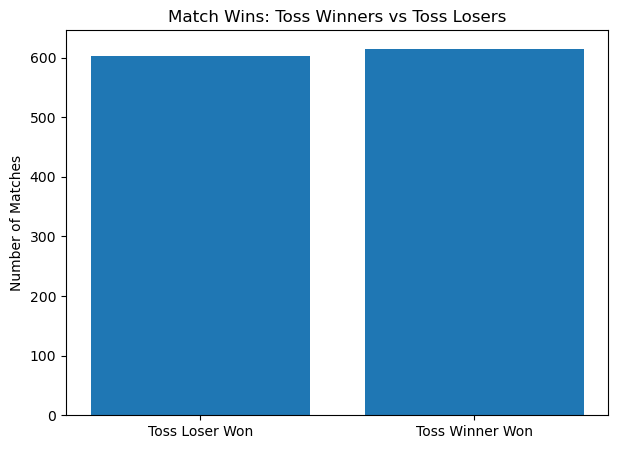

Toss winners won 50.49% matches


In [2]:
# Remove duplicate matches
matches = ipl.drop_duplicates(subset=['match_id'])

# Toss winner also won?
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']

# Count wins
counts = matches['toss_match_win'].value_counts()

# Labels
labels = ['Toss Loser Won', 'Toss Winner Won']
values = [counts[False], counts[True]]

# Plot
plt.figure(figsize=(7,5))
plt.bar(labels, values)
plt.title('Match Wins: Toss Winners vs Toss Losers')
plt.ylabel('Number of Matches')
plt.show()

# Percentages
win_percent = (counts[True] / counts.sum()) * 100
print(f"Toss winners won {win_percent:.2f}% matches")

## Observation

The analysis shows that toss winners won only slightly more matches than toss losers.

This suggests that while the toss provides some advantage, match performance matters much more than toss outcome.

# Question 2 — Match Phase Analysis

A T20 innings can be divided into three important phases:

| Phase | Overs |
|---|---|
| Powerplay | 1–6 |
| Middle Overs | 7–15 |
| Death Overs | 16–20 |

This analysis compares scoring patterns between winning and losing teams during each phase.

In [3]:
# Function for phases

def get_phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle Overs'
    else:
        return 'Death Overs'

# Apply function
ipl['phase'] = ipl['over'].apply(get_phase)

In [4]:
# Winning team batting?
ipl['team_result'] = ipl.apply(
    lambda x: 'Winner' if x['batting_team'] == x['winner'] else 'Loser',
    axis=1
)

In [5]:
phase_runs = ipl.groupby(['phase', 'team_result'])['runs_total'].mean().reset_index()

print(phase_runs)

          phase team_result  runs_total
0   Death Overs       Loser    1.480574
1   Death Overs      Winner    1.812067
2  Middle Overs       Loser    1.235257
3  Middle Overs      Winner    1.399953
4     Powerplay       Loser    1.193388
5     Powerplay      Winner    1.345310


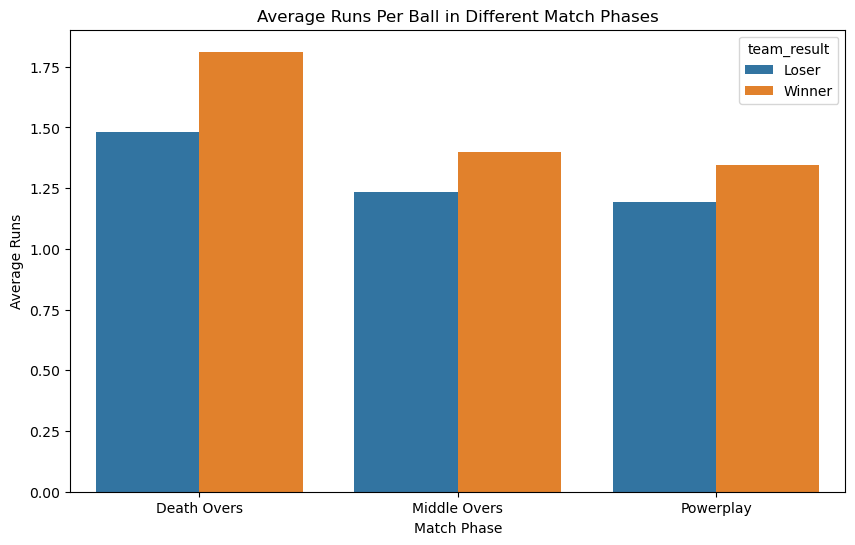

In [6]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=phase_runs,
    x='phase',
    y='runs_total',
    hue='team_result'
)

plt.title('Average Runs Per Ball in Different Match Phases')
plt.ylabel('Average Runs')
plt.xlabel('Match Phase')

plt.show()

## Observation

The biggest scoring difference between winning and losing teams occurred during the death overs.

Winning teams consistently scored at a faster rate in overs 16–20, showing that strong finishing plays a critical role in IPL victories.

# Question 3 — Top Batters Analysis

This section identifies the highest run-scoring batters across the most recent five IPL seasons.

In [14]:
# Get latest 5 seasons
latest_seasons = sorted(ipl['season'].unique())[-5:]

ipl_5 = ipl[ipl['season'].isin(latest_seasons)]

print(latest_seasons)

['2022', '2023', '2024', '2025', '2026']


In [8]:
batters = (
    ipl_5.groupby('batter')['runs_batter']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(batters)

batter
Shubman Gill    2827
V Kohli         2757
JC Buttler      2487
KL Rahul        2401
YBK Jaiswal     2189
Name: runs_batter, dtype: int64


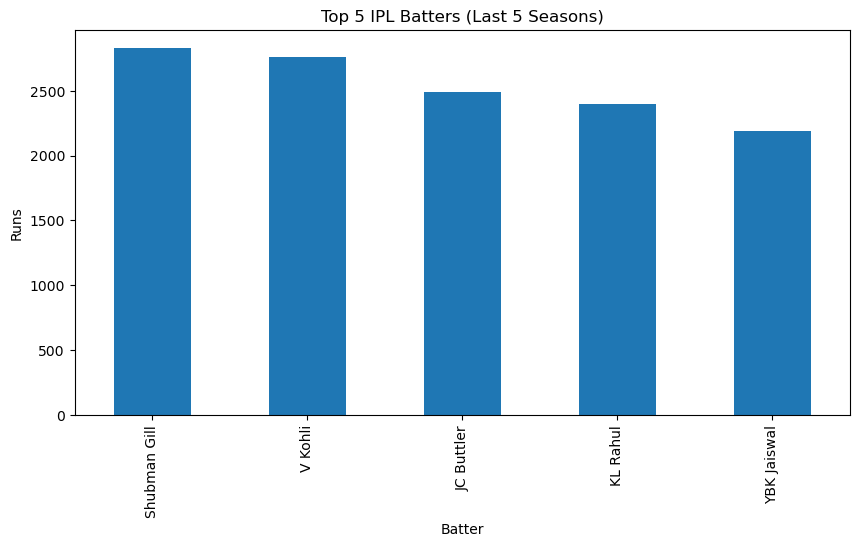

In [9]:
plt.figure(figsize=(10,5))

batters.plot(kind='bar')

plt.title('Top 5 IPL Batters (Last 5 Seasons)')
plt.ylabel('Runs')
plt.xlabel('Batter')

plt.show()

## Observation

The top batters demonstrated remarkable consistency across multiple seasons.

Their ability to maintain high run totals highlights their importance in match-winning performances.

# Top Bowlers Analysis

This section identifies the bowlers with the highest wicket counts across recent IPL seasons.

Only valid bowling dismissals are considered in this analysis.

In [10]:
valid_wickets = ipl_5[
    (~ipl_5['wicket_kind'].isna()) &
    (ipl_5['wicket_kind'] != 'run out')
]

bowlers = (
    valid_wickets.groupby('bowler')['wicket_player_out']
    .count()
    .sort_values(ascending=False)
    .head(5)
)

print(bowlers)

bowler
YS Chahal         90
Arshdeep Singh    78
Rashid Khan       76
CV Varun          74
B Kumar           74
Name: wicket_player_out, dtype: int64


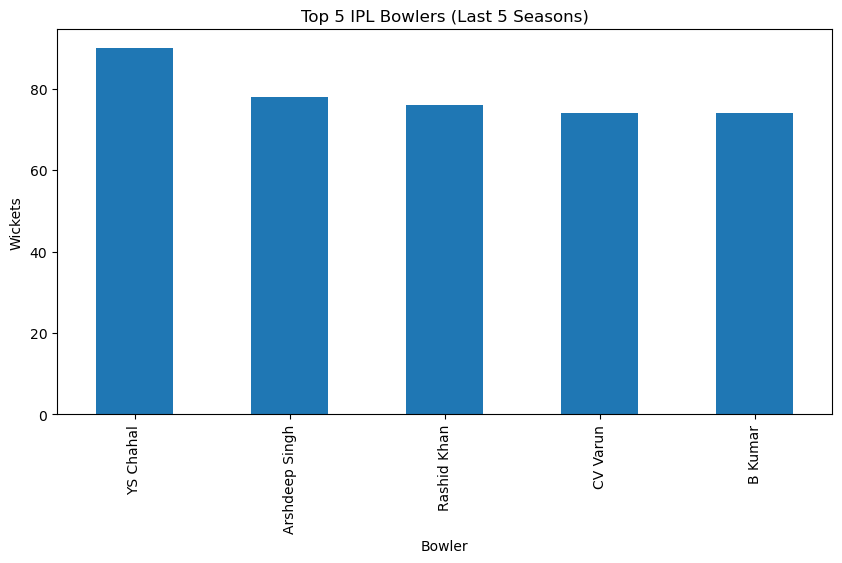

In [11]:
plt.figure(figsize=(10,5))

bowlers.plot(kind='bar')

plt.title('Top 5 IPL Bowlers (Last 5 Seasons)')
plt.ylabel('Wickets')
plt.xlabel('Bowler')

plt.show()

## Observation

The leading wicket-taking bowlers consistently created breakthroughs for their teams, making them highly impactful players in the tournament.

# Chasing vs Defending Analysis


win_type
Defending Win    622
Chasing Win      596
Name: count, dtype: int64


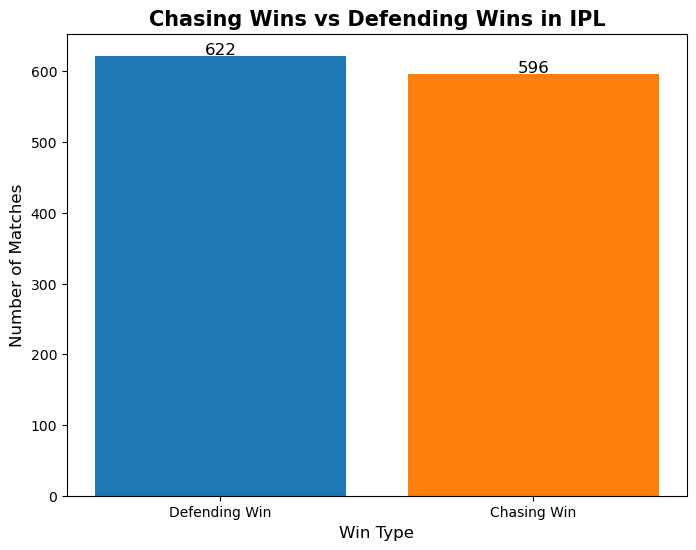

Chasing Win Percentage: 48.93%
Defending Win Percentage: 51.07%


In [18]:

# Remove duplicate matches
matches = ipl.drop_duplicates(subset=['match_id']).copy()

# Team batting first
matches['bat_first'] = matches['team1']

# Team batting second
matches['bat_second'] = matches['team2']

# Determine win type
matches['win_type'] = matches.apply(
    lambda x: 'Chasing Win'
    if x['winner'] == x['bat_second']
    else 'Defending Win',
    axis=1
)

# Count wins
win_counts = matches['win_type'].value_counts()

print(win_counts)

# ----------------------------------------
# Visualization
# ----------------------------------------

plt.figure(figsize=(8,6))

colors = ['#1f77b4', '#ff7f0e']

bars = plt.bar(
    win_counts.index,
    win_counts.values,
    color=colors
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(height),
        ha='center',
        fontsize=12
    )

plt.title(
    'Chasing Wins vs Defending Wins in IPL',
    fontsize=15,
    fontweight='bold'
)

plt.ylabel('Number of Matches', fontsize=12)
plt.xlabel('Win Type', fontsize=12)

plt.show()

# ----------------------------------------
# Percentages
# ----------------------------------------

chasing_percent = (
    win_counts['Chasing Win'] / win_counts.sum()
) * 100

defending_percent = (
    win_counts['Defending Win'] / win_counts.sum()
) * 100

print(f"Chasing Win Percentage: {chasing_percent:.2f}%")
print(f"Defending Win Percentage: {defending_percent:.2f}%")

## Observation

Although chasing is often considered easier in T20 cricket, the analysis showed that teams defending totals also won a significant number of matches.

This suggests that strong bowling performances and scoreboard pressure still make defending highly effective in IPL matches.

# Key Surprising Insight

Despite popular IPL beliefs, neither winning the toss nor chasing guarantees victory.

The analysis showed that toss winners won only slightly more than half the matches, while teams defending totals also secured a surprisingly high number of wins.

This suggests that match execution — especially during death overs — has a much greater impact on results than toss advantage or batting order.

# Conclusion

This IPL data analysis project explored how toss decisions, scoring phases, and player performances influence match outcomes.

Key findings include:

- Toss advantage exists but is relatively small
- Death overs are the most decisive phase of a match
- Consistent performers dominate across multiple seasons

The project demonstrates how ball-by-ball cricket data can be used to uncover meaningful insights through data analysis and visualization.

# Thank You

This project was created as part of the Wooble IPL Data Analysis Challenge.